In [2]:
import pandas as pd
df = pd.read_csv(r"salaries.csv")

df.head()





,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0


In [4]:
#Independent variables
inputs = df.drop('salary_more_then_100k', axis='columns')
target = df['salary_more_then_100k']

In [6]:
inputs

,company,job,degree
0,google,sales executive,bachelors
1,google,sales executive,masters
2,google,business manager,bachelors
3,google,business manager,masters
4,google,computer programmer,bachelors
5,google,computer programmer,masters
6,abc pharma,sales executive,masters
7,abc pharma,computer programmer,bachelors
8,abc pharma,business manager,bachelors
9,abc pharma,business manager,masters


In [7]:
#use label encoder to convert string to numbers
from sklearn.preprocessing import LabelEncoder


In [8]:
le_company = LabelEncoder()
le_job = LabelEncoder()
le_degree = LabelEncoder()


In [9]:
inputs['company_n']= le_company.fit_transform(inputs['company'])
inputs['job_n']= le_job.fit_transform(inputs['job'])
inputs['degree_n']= le_degree.fit_transform(inputs['degree'])
inputs.head()

,company,job,degree,company_n,job_n,degree_n
0,google,sales executive,bachelors,2,2,0
1,google,sales executive,masters,2,2,1
2,google,business manager,bachelors,2,0,0
3,google,business manager,masters,2,0,1
4,google,computer programmer,bachelors,2,1,0


In [10]:
inputs_n = inputs.drop(['company','job','degree'], axis='columns')
inputs_n.head()

,company_n,job_n,degree_n
0,2,2,0
1,2,2,1
2,2,0,0
3,2,0,1
4,2,1,0


In [11]:
from sklearn import tree
model = tree.DecisionTreeClassifier()
model.fit(inputs_n, target)

DecisionTreeClassifier()

### Decision tree model

In the code below we are creating and training a `DecisionTreeClassifier` from `sklearn.tree`:

```python
from sklearn import tree
model = tree.DecisionTreeClassifier()
model.fit(inputs_n, target)
```

Some of the most commonly used parameters of `DecisionTreeClassifier` are:

- **criterion**: The function used to measure the quality of a split.
  - `'gini'` (default): Gini impurity.
  - `'entropy'`: Information gain based on entropy.
- **max_depth**: Maximum depth of the tree.
  - `None` (default) means the nodes are expanded until all leaves are pure or until all leaves contain fewer than `min_samples_split` samples.
  - Use a smaller integer (e.g. `3`, `5`, `10`) to limit tree growth and reduce overfitting.
- **min_samples_split**: Minimum number of samples required to split an internal node.
  - Default is `2`. Larger values (e.g. `5`, `10`) make the tree more conservative.
- **min_samples_leaf**: Minimum number of samples required to be at a leaf node.
  - Default is `1`. Increasing this can smooth the model and reduce overfitting.
- **max_features**: Number of features to consider when looking for the best split.
  - `None` (default) means all features.
  - You can also pass an integer, a float (fraction of features), or strings like `'sqrt'`, `'log2'`.
- **random_state**: Controls the randomness of the estimator.
  - Set it to an integer (e.g. `42`) for reproducible results.

Example of creating a tree with explicit hyperparameters:

```python
model = tree.DecisionTreeClassifier(
    criterion="gini",      # how to measure split quality
    max_depth=3,            # maximum depth of the tree
    min_samples_split=2,    # min samples needed to split a node
    min_samples_leaf=1,     # min samples required at a leaf node
    random_state=42         # seed for reproducibility
)
model.fit(inputs_n, target)
```

In [12]:
model.score(inputs_n, target)

1.0

In [13]:
model.predict([[2,2,1]])

c:\Users\varsv\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [14]:
model.predict([[0,0,0]])

c:\Users\varsv\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

#Excercise survival prediction titanic dataset


In [36]:
import pandas as pd
df  = pd.read_csv(r"titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [37]:
df.drop(['PassengerId','Name','Ticket','Cabin'], axis='columns', inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [38]:
from sklearn.preprocessing import LabelEncoder
le_sex = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])
le_embarked = LabelEncoder()
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])


In [39]:
#Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [40]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [41]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [42]:
X= df[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
y = df['Survived']


In [43]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [50]:
from sklearn import tree
model = tree.DecisionTreeClassifier(criterion='entropy',max_depth=3,random_state=42,min_samples_split=5,min_samples_leaf=2,max_leaf_nodes=10,class_weight='balanced')
model.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=3, max_leaf_nodes=10, min_samples_leaf=2,
                       min_samples_split=5, random_state=42)

In [51]:
model.score(X_test,y_test)

0.7988826815642458

In [52]:
model.predict([[3,0,22,1,0,7.25,0]])

c:\Users\varsv\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

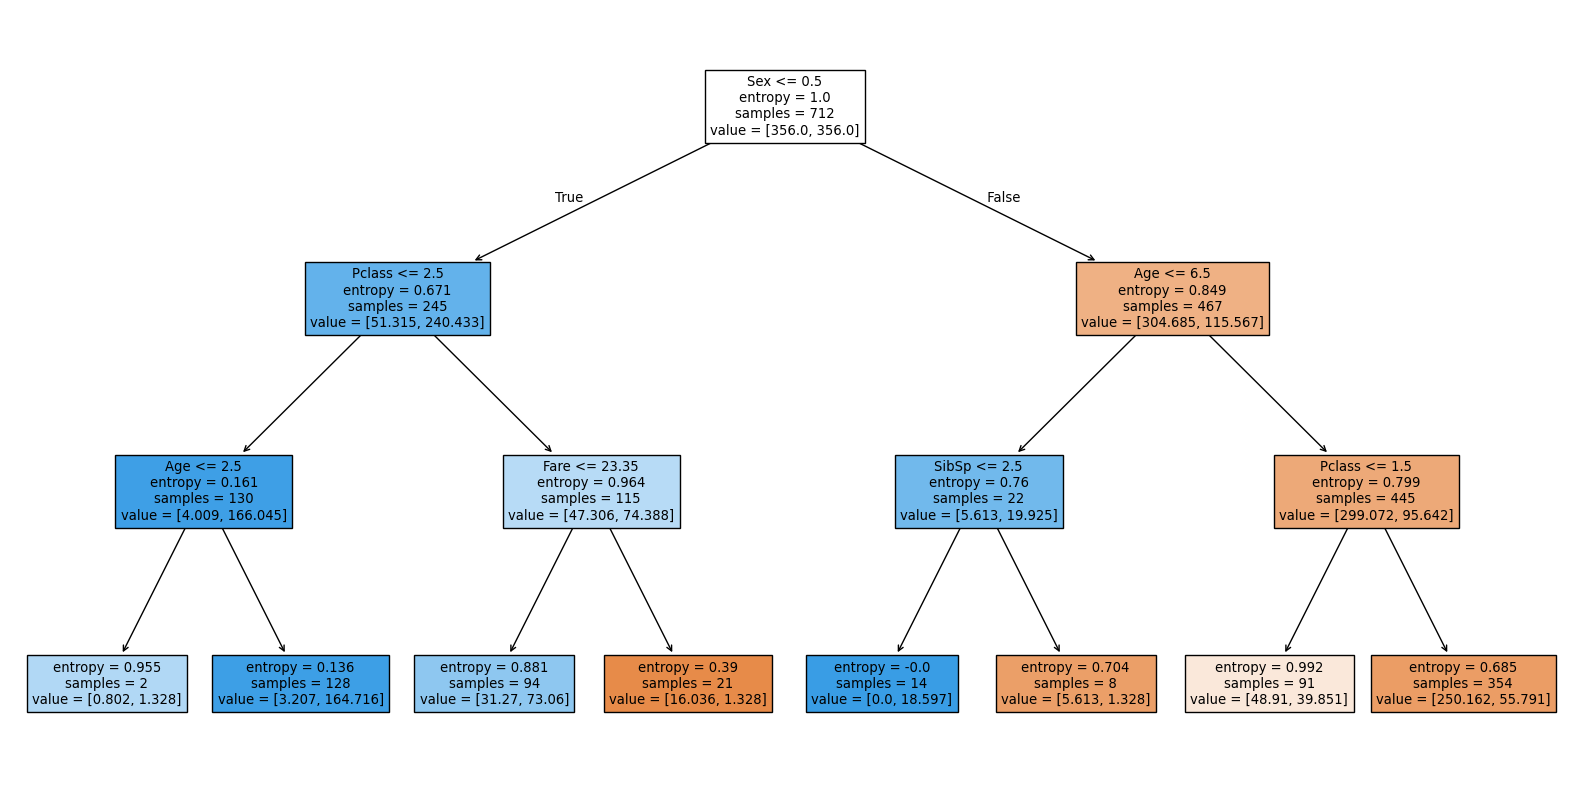

In [53]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(model,feature_names = X.columns, filled=True)
plt.show()

In [54]:
#Feature importance
importance = model.feature_importances_
for i,v in enumerate(importance):
    print(X.columns[i],v)

Pclass 0.2402333273574651
Sex 0.5586124960339554
Age 0.0851631523673161
SibSp 0.050788040838357855
Parch 0.0
Fare 0.06520298340290555
Embarked 0.0
